# Notebook 02: Contextual Drag — Full LLM Reproduction

**Week 12 · ICLR 2026 RSI Workshop · GPU Required (24GB+ VRAM)**

---

## What This Notebook Reproduces

Full reproduction of the key experiments from *Contextual Drag: How Errors in the Context Affect LLM Reasoning* (Cheng et al., ICLR 2026 RSI Workshop Oral).

The paper demonstrates across 11 models on 8 reasoning tasks that failed attempts in context induce **10–20% performance drops** with structural error inheritance. We reproduce this across two Qwen2.5 model sizes (0.5B and 3B) on GSM8K and ARC-Challenge, spanning a 6× capability gap to test whether drag severity scales with model size.

**Paper:** [OpenReview](https://openreview.net/forum?id=zpiYsPVDlV)
**Code:** [princeton-pli/contextual-drag](https://github.com/princeton-pli/contextual-drag)

**Connection to NB 00:** Notebook 00 demonstrated the phenomenon on a toy task with a simulated model. This notebook tests whether the same patterns hold with real LLMs — where error patterns are richer, reasoning traces are more complex, and the drag phenomenon is measured via actual generation behavior rather than logistic probabilities.

**Important caveat:** Reproducing paper results exactly is unlikely — differences in sampling, quantization, prompt formatting, and evaluation parsing all introduce variance. Our goal is to test whether the core findings (context degrades performance, structured errors cause step-localized inheritance) hold directionally, not to match the paper's exact numbers.

### What We Cover

1. **Baseline** — clean-context performance across models and benchmarks
2. **Error context** — 1, 2, 3 failed attempts prepended (the core drag experiment)
3. **Error + correction** — failed attempts followed by explicit corrections
4. **External feedback** — failed attempts with verifier feedback
5. **Structural analysis** — do new errors resemble context errors? (ROUGE-L + step overlap)
6. **Cross-model comparison** — does drag severity scale with model size?

### Compute Requirements
- GPU: 24GB+ VRAM (A100, H100, or RTX 4090 recommended)
- 4-bit quantization for all models
- Estimated runtime: ~13 hours on A100 (dominated by wrong-solution cache generation)

## Section 1: Setup & Dependencies

In [1]:
import shutil
import subprocess
import sys

# Auto-detect installer: prefer uv, fall back to pip
UV_AVAILABLE = shutil.which("uv") is not None
installer = "uv pip" if UV_AVAILABLE else f"{sys.executable} -m pip"

PACKAGES = [
    "transformers>=4.40.0",
    "torch",
    "bitsandbytes",
    "peft",
    "datasets",
    "accelerate",
    "matplotlib",
    "rouge-score",
]

if UV_AVAILABLE:
    print("Using uv (detected on PATH)")
    subprocess.check_call(["uv", "pip", "install", "-q"] + PACKAGES)
else:
    print(
        "Using pip (uv not found — install uv for faster setup: "
        "https://docs.astral.sh/uv/)"
    )
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + PACKAGES)

print(f"\n✓ Installer: {'uv' if UV_AVAILABLE else 'pip'}")
print("✓ Dependencies installed")

Using uv (detected on PATH)



✓ Installer: uv
✓ Dependencies installed


In [2]:
import gc
import json
import random
import re
import time
import warnings
from collections import defaultdict

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Set random seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# =====================================================================
# GPU Detection
# =====================================================================
NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    name = torch.cuda.get_device_name(i)
    mem_gb = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem_gb:.1f} GB)")

if NUM_GPUS == 0:
    print("\n⚠ No GPU detected. This notebook requires a GPU with 24GB+ VRAM.")
    print("  Results on CPU will be extremely slow and are not recommended.")
else:
    print(f"\n✓ All dependencies loaded successfully")
    print(f"✓ Models will be pinned to a single GPU (configurable via EVAL_GPU)")
    print(f"  Even with multi-GPU, we pin to one GPU for inference —")
    print(f"  4-bit models are small enough and this avoids sharding overhead.")

GPUs available: 8
  GPU 0: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 1: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 2: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 3: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 4: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 5: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 6: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 7: NVIDIA H100 80GB HBM3 (85.3 GB)

✓ All dependencies loaded successfully
✓ Models will be pinned to a single GPU (configurable via EVAL_GPU)
  Even with multi-GPU, we pin to one GPU for inference —
  4-bit models are small enough and this avoids sharding overhead.


## Section 2: Configuration & Model Loading

We test across two Qwen2.5-Instruct model sizes (0.5B and 3B) with 4-bit quantization to compare drag severity across a 6× capability gap. All models use the same prompt templates and evaluation logic.

**Models:** 0.5B, 3B (both Qwen2.5-Instruct, 4-bit NF4)
**Benchmarks:** GSM8K (math reasoning), ARC-Challenge (multi-step science reasoning)
**Eval subset:** 100 samples per benchmark (configurable — increase for tighter estimates)

In [3]:
# =====================================================================
# Configuration
# =====================================================================

# Models to evaluate (smallest to largest)
MODEL_IDS = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
]

# GPU selection — pin all inference to a single GPU.
# With 4-bit quantization, even 7B fits comfortably on one 24GB GPU.
# Change this if you want to use a different GPU (e.g., EVAL_GPU = 7).
EVAL_GPU = 0

# Evaluation settings
N_EVAL_SAMPLES = 100  # per benchmark; increase to 500+ for tighter confidence intervals
MAX_NEW_TOKENS = 512  # max tokens for generation
TEMPERATURE = 0.7  # for error generation (wrong solutions)
NUM_ERROR_COUNTS = [1, 2, 3]  # how many failed attempts to prepend

# 4-bit quantization config
BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Models: {len(MODEL_IDS)}")
print(f"Eval GPU: {EVAL_GPU}")
print(f"Eval samples per benchmark: {N_EVAL_SAMPLES}")
print(f"Error context counts to test: {NUM_ERROR_COUNTS}")


# =====================================================================
# Model loading utility
# =====================================================================


def load_model_and_tokenizer(model_id):
    """Load a model with 4-bit quantization pinned to a single GPU."""
    print(f"\nLoading {model_id} on GPU {EVAL_GPU}...")
    t0 = time.time()

    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Pin to single GPU — avoids multi-GPU sharding overhead for small models
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=BNB_CONFIG,
        device_map={"": EVAL_GPU},
        trust_remote_code=True,
    )
    model.eval()

    elapsed = time.time() - t0
    mem_gb = torch.cuda.max_memory_allocated(EVAL_GPU) / 1e9 if NUM_GPUS > 0 else 0
    print(f"  Loaded in {elapsed:.1f}s, GPU {EVAL_GPU} memory: {mem_gb:.1f} GB")

    return model, tokenizer


def unload_model(model):
    """Free GPU memory after evaluating a model."""
    del model
    gc.collect()
    if NUM_GPUS > 0:
        torch.cuda.empty_cache()
    print("  Model unloaded, GPU memory freed.")


# =====================================================================
# Load benchmarks
# =====================================================================

print("\nLoading benchmarks...")

# GSM8K: math word problems
gsm8k = load_dataset("openai/gsm8k", "main", split="test")
gsm8k_subset = gsm8k.shuffle(seed=42).select(range(min(N_EVAL_SAMPLES, len(gsm8k))))
print(f"  GSM8K: {len(gsm8k_subset)} samples (from {len(gsm8k)} total)")

# ARC-Challenge: science multiple choice
arc = load_dataset("allenai/ai2_arc", "ARC-Challenge", split="test")
arc_subset = arc.shuffle(seed=42).select(range(min(N_EVAL_SAMPLES, len(arc))))
print(f"  ARC-Challenge: {len(arc_subset)} samples (from {len(arc)} total)")


# =====================================================================
# Answer extraction utilities
# =====================================================================


def extract_gsm8k_answer(text):
    """Extract numeric answer from GSM8K generation.

    GSM8K answers are typically after '####' or the last number in the text.
    """
    # Try #### pattern first
    match = re.search(r"####\s*([-\d,]+)", text)
    if match:
        return match.group(1).replace(",", "").strip()

    # Try "the answer is" pattern
    match = re.search(r"(?:the answer is|answer:)\s*([-\d,]+)", text, re.IGNORECASE)
    if match:
        return match.group(1).replace(",", "").strip()

    # Fall back to last number in text
    numbers = re.findall(r"[-\d,]+", text)
    if numbers:
        return numbers[-1].replace(",", "").strip()

    return ""


def extract_gsm8k_ground_truth(answer_text):
    """Extract ground truth from GSM8K answer field."""
    match = re.search(r"####\s*([-\d,]+)", answer_text)
    if match:
        return match.group(1).replace(",", "").strip()
    return answer_text.strip()


def extract_arc_answer(text, choices):
    """Extract answer choice (A/B/C/D) from ARC generation."""
    # Look for explicit "Answer: X" or "(X)" pattern
    match = re.search(r"(?:answer|choice)[\s:]*([A-D])", text, re.IGNORECASE)
    if match:
        return match.group(1).upper()

    # Look for standalone letter at the end
    match = re.search(r"\b([A-D])\b\s*$", text.strip())
    if match:
        return match.group(1).upper()

    # Look for first mention of A/B/C/D after reasoning
    match = re.search(r"\b([A-D])\b", text)
    if match:
        return match.group(1).upper()

    return ""


print("\nSetup complete.")

Models: 2
Eval GPU: 0
Eval samples per benchmark: 100
Error context counts to test: [1, 2, 3]

Loading benchmarks...


  GSM8K: 100 samples (from 1319 total)


  ARC-Challenge: 100 samples (from 1172 total)

Setup complete.


## Section 3: Prompt Templates & Generation Infrastructure

We define prompt templates for both benchmarks, plus variants for injecting error context.

In [4]:
# =====================================================================
# Prompt templates
# =====================================================================

# --- GSM8K ---
GSM8K_CLEAN_PROMPT = """Solve the following math problem step by step. Show your reasoning, then give the final answer after ####.

Problem: {question}

Solution:"""

GSM8K_ERROR_CONTEXT_PROMPT = """Solve the following math problem step by step. Show your reasoning, then give the final answer after ####.

Problem: {question}

{error_context}Now try to solve this problem correctly:

Solution:"""

GSM8K_ERROR_CORRECTION_PROMPT = """Solve the following math problem step by step. Show your reasoning, then give the final answer after ####.

Problem: {question}

{error_context}The above attempt(s) were incorrect. The errors were in the reasoning steps. Please solve this problem correctly from scratch:

Solution:"""

GSM8K_FEEDBACK_PROMPT = """Solve the following math problem step by step. Show your reasoning, then give the final answer after ####.

Problem: {question}

{error_context}{feedback}
Now solve this problem correctly:

Solution:"""

# --- ARC-Challenge ---
ARC_CLEAN_PROMPT = """Answer the following multiple-choice question. Think step by step, then give your final answer as a single letter (A, B, C, or D).

Question: {question}
{choices}

Answer:"""

ARC_ERROR_CONTEXT_PROMPT = """Answer the following multiple-choice question. Think step by step, then give your final answer as a single letter (A, B, C, or D).

Question: {question}
{choices}

{error_context}Now try to answer this question correctly:

Answer:"""

ARC_ERROR_CORRECTION_PROMPT = """Answer the following multiple-choice question. Think step by step, then give your final answer as a single letter (A, B, C, or D).

Question: {question}
{choices}

{error_context}The above attempt(s) were incorrect. Please reconsider and answer correctly:

Answer:"""

ARC_FEEDBACK_PROMPT = """Answer the following multiple-choice question. Think step by step, then give your final answer as a single letter (A, B, C, or D).

Question: {question}
{choices}

{error_context}{feedback}
Now answer this question correctly:

Answer:"""


def format_arc_choices(example):
    """Format ARC choices as A) ... B) ... etc."""
    labels = example["choices"]["label"]
    texts = example["choices"]["text"]
    return "\n".join(f"{l}) {t}" for l, t in zip(labels, texts))


# =====================================================================
# Generation utilities
# =====================================================================


@torch.no_grad()
def generate_response(
    model, tokenizer, prompt, temperature=0.0, max_new_tokens=MAX_NEW_TOKENS
):
    """Generate a response from the model.

    Args:
        temperature: 0.0 for greedy (evaluation), >0 for sampling (error generation)
    """
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "pad_token_id": tokenizer.pad_token_id,
    }
    if temperature > 0:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = 0.95

    outputs = model.generate(**inputs, **gen_kwargs)
    # Decode only the new tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[1] :]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()


def generate_wrong_solution(
    model,
    tokenizer,
    prompt,
    correct_answer,
    benchmark="gsm8k",
    max_attempts=5,
    choices=None,
):
    """Generate a wrong solution by sampling at high temperature and filtering.

    Returns the wrong solution text, or None if we can't generate one.
    """
    for _ in range(max_attempts):
        response = generate_response(model, tokenizer, prompt, temperature=TEMPERATURE)
        if benchmark == "gsm8k":
            predicted = extract_gsm8k_answer(response)
            if predicted != correct_answer and len(response) > 20:
                return response
        elif benchmark == "arc":
            predicted = extract_arc_answer(response, choices)
            if predicted != correct_answer and len(response) > 10:
                return response
    return None


print("Prompt templates and generation utilities defined.")

Prompt templates and generation utilities defined.


## Section 4: Main Evaluation Loop

This is the core experiment. For each model × benchmark × condition, we:
1. Generate baseline (clean) predictions
2. Generate wrong solutions for each problem (via temperature sampling)
3. Prepend 1, 2, 3 wrong solutions as context and re-evaluate
4. Test error+correction and external feedback at ×1
5. Store all reasoning traces for structural analysis later

**Conditions tested:**
- `clean`: no context (baseline)
- `error_N`: N wrong solutions prepended (N = 1, 2, 3)
- `correction_1`: 1 wrong solution + explicit correction note
- `feedback_1`: 1 wrong solution + verifier feedback identifying the error

In [5]:
# =====================================================================
# Main evaluation engine
# =====================================================================


def evaluate_gsm8k(
    model, tokenizer, dataset, condition="clean", n_errors=0, wrong_solutions_cache=None
):
    """Evaluate model on GSM8K under a specific context condition.

    Args:
        condition: "clean", "error", "correction", "feedback"
        n_errors: number of wrong solutions to prepend (ignored if clean)
        wrong_solutions_cache: dict of {idx: [list of wrong solutions]}

    Returns: dict with accuracy, per-sample results, and traces
    """
    correct = 0
    results = []

    for idx, example in enumerate(dataset):
        question = example["question"]
        gt_answer = extract_gsm8k_ground_truth(example["answer"])

        if condition == "clean":
            prompt = GSM8K_CLEAN_PROMPT.format(question=question)
        else:
            # Build error context
            wrong_sols = wrong_solutions_cache.get(idx, [])
            if len(wrong_sols) < n_errors:
                # Not enough wrong solutions — skip this sample
                results.append(
                    {"idx": idx, "skipped": True, "reason": "insufficient_errors"}
                )
                continue

            error_parts = []
            for i, wsol in enumerate(wrong_sols[:n_errors]):
                error_parts.append(f"Previous attempt {i + 1} (incorrect):\n{wsol}\n")
            error_context = "\n".join(error_parts)

            if condition == "error":
                prompt = GSM8K_ERROR_CONTEXT_PROMPT.format(
                    question=question, error_context=error_context
                )
            elif condition == "correction":
                prompt = GSM8K_ERROR_CORRECTION_PROMPT.format(
                    question=question, error_context=error_context
                )
            elif condition == "feedback":
                feedback = f"A verifier checked the above {n_errors} attempt(s) and found errors in the reasoning steps."
                prompt = GSM8K_FEEDBACK_PROMPT.format(
                    question=question, error_context=error_context, feedback=feedback
                )

        response = generate_response(model, tokenizer, prompt, temperature=0.0)
        predicted = extract_gsm8k_answer(response)
        is_correct = predicted == gt_answer

        if is_correct:
            correct += 1

        results.append(
            {
                "idx": idx,
                "question": question,
                "gt_answer": gt_answer,
                "predicted": predicted,
                "correct": is_correct,
                "response": response,
                "condition": condition,
                "n_errors": n_errors,
                "skipped": False,
            }
        )

    n_evaluated = sum(1 for r in results if not r.get("skipped", False))
    accuracy = correct / n_evaluated if n_evaluated > 0 else 0.0

    return {
        "accuracy": accuracy,
        "correct": correct,
        "n_evaluated": n_evaluated,
        "n_skipped": len(results) - n_evaluated,
        "results": results,
    }


def evaluate_arc(
    model, tokenizer, dataset, condition="clean", n_errors=0, wrong_solutions_cache=None
):
    """Evaluate model on ARC-Challenge under a specific context condition."""
    correct = 0
    results = []

    for idx, example in enumerate(dataset):
        question = example["question"]
        choices_str = format_arc_choices(example)
        gt_answer = example["answerKey"]
        choices = example["choices"]

        if condition == "clean":
            prompt = ARC_CLEAN_PROMPT.format(question=question, choices=choices_str)
        else:
            wrong_sols = wrong_solutions_cache.get(idx, [])
            if len(wrong_sols) < n_errors:
                results.append(
                    {"idx": idx, "skipped": True, "reason": "insufficient_errors"}
                )
                continue

            error_parts = []
            for i, wsol in enumerate(wrong_sols[:n_errors]):
                error_parts.append(f"Previous attempt {i + 1} (incorrect):\n{wsol}\n")
            error_context = "\n".join(error_parts)

            if condition == "error":
                prompt = ARC_ERROR_CONTEXT_PROMPT.format(
                    question=question, choices=choices_str, error_context=error_context
                )
            elif condition == "correction":
                prompt = ARC_ERROR_CORRECTION_PROMPT.format(
                    question=question, choices=choices_str, error_context=error_context
                )
            elif condition == "feedback":
                feedback = f"A verifier checked the above {n_errors} attempt(s) and found the chosen answers were wrong."
                prompt = ARC_FEEDBACK_PROMPT.format(
                    question=question,
                    choices=choices_str,
                    error_context=error_context,
                    feedback=feedback,
                )

        response = generate_response(model, tokenizer, prompt, temperature=0.0)
        predicted = extract_arc_answer(response, choices)
        is_correct = predicted == gt_answer

        if is_correct:
            correct += 1

        results.append(
            {
                "idx": idx,
                "question": question,
                "gt_answer": gt_answer,
                "predicted": predicted,
                "correct": is_correct,
                "response": response,
                "condition": condition,
                "n_errors": n_errors,
                "skipped": False,
            }
        )

    n_evaluated = sum(1 for r in results if not r.get("skipped", False))
    accuracy = correct / n_evaluated if n_evaluated > 0 else 0.0

    return {
        "accuracy": accuracy,
        "correct": correct,
        "n_evaluated": n_evaluated,
        "n_skipped": len(results) - n_evaluated,
        "results": results,
    }


def generate_wrong_solutions_cache(
    model, tokenizer, dataset, benchmark="gsm8k", n_needed=3
):
    """Pre-generate wrong solutions for all examples in a dataset.

    Returns: dict of {idx: [list of wrong solution texts]}
    """
    cache = {}
    n_failed = 0

    for idx, example in enumerate(dataset):
        if benchmark == "gsm8k":
            question = example["question"]
            gt_answer = extract_gsm8k_ground_truth(example["answer"])
            prompt = GSM8K_CLEAN_PROMPT.format(question=question)
            choices = None
        elif benchmark == "arc":
            question = example["question"]
            choices_str = format_arc_choices(example)
            gt_answer = example["answerKey"]
            prompt = ARC_CLEAN_PROMPT.format(question=question, choices=choices_str)
            choices = example["choices"]

        wrong_sols = []
        for _ in range(n_needed):
            wsol = generate_wrong_solution(
                model,
                tokenizer,
                prompt,
                gt_answer,
                benchmark=benchmark,
                choices=choices,
            )
            if wsol is not None:
                wrong_sols.append(wsol)

        cache[idx] = wrong_sols
        if len(wrong_sols) < n_needed:
            n_failed += 1

        if (idx + 1) % 50 == 0:
            print(
                f"    Generated wrong solutions for {idx + 1}/{len(dataset)} examples"
            )

    print(
        f"  Wrong solutions generated. {n_failed}/{len(dataset)} examples with < {n_needed} errors"
    )
    return cache


print("Evaluation engine defined.")

Evaluation engine defined.


## Section 5: Run All Experiments

This cell runs the full experiment matrix. Actual runtime: ~765 min (~12.75h) on A100, dominated by wrong-solution cache generation.

For each model:
1. Load model
2. Evaluate clean baseline on both benchmarks
3. Generate wrong solutions cache
4. Evaluate error context (1, 2, 3 errors) + correction×1 + feedback×1
5. Store all traces for structural analysis
6. Unload model, free GPU memory

In [6]:
# =====================================================================
# Run full experiment matrix
# =====================================================================

# Core drag sweep: error × [1,2,3]. Correction and feedback at ×1 only
# (sufficient to show framing effect without 3× runtime cost).
CONDITION_GRID = [
    ("error", 1),
    ("error", 2),
    ("error", 3),
    ("correction", 1),
    ("feedback", 1),
]

all_experiment_results = {}  # key: (model_short_name, benchmark, condition, n_errors)
all_traces = {}  # key: (model_short_name, benchmark) -> list of per-sample dicts

total_start = time.time()

for model_id in MODEL_IDS:
    model_name = model_id.split("/")[-1]  # e.g. "Qwen2.5-3B-Instruct"
    print(f"\n{'=' * 70}")
    print(f"MODEL: {model_name}")
    print(f"{'=' * 70}")

    model, tokenizer = load_model_and_tokenizer(model_id)

    for benchmark, dataset, eval_fn in [
        ("gsm8k", gsm8k_subset, evaluate_gsm8k),
        ("arc", arc_subset, evaluate_arc),
    ]:
        print(f"\n  --- {benchmark.upper()} ---")

        # 1. Clean baseline
        print(f"  Evaluating clean baseline...")
        t0 = time.time()
        clean_result = eval_fn(model, tokenizer, dataset, condition="clean")
        elapsed = time.time() - t0
        key = (model_name, benchmark, "clean", 0)
        all_experiment_results[key] = clean_result
        print(
            f"    Clean: {clean_result['accuracy']:.1%} "
            f"({clean_result['correct']}/{clean_result['n_evaluated']}) "
            f"[{elapsed:.0f}s]"
        )

        # 2. Generate wrong solutions cache
        print(f"  Generating wrong solutions cache...")
        t0 = time.time()
        wrong_cache = generate_wrong_solutions_cache(
            model, tokenizer, dataset, benchmark=benchmark, n_needed=3
        )
        elapsed = time.time() - t0
        print(f"    Cache built in {elapsed:.0f}s")

        # 3. Evaluate trimmed condition grid
        for condition, n_errors in CONDITION_GRID:
            print(f"  Evaluating {condition} (n_errors={n_errors})...")
            t0 = time.time()
            result = eval_fn(
                model,
                tokenizer,
                dataset,
                condition=condition,
                n_errors=n_errors,
                wrong_solutions_cache=wrong_cache,
            )
            elapsed = time.time() - t0

            key = (model_name, benchmark, condition, n_errors)
            all_experiment_results[key] = result

            delta = (result["accuracy"] - clean_result["accuracy"]) * 100
            print(
                f"    {condition}_{n_errors}: {result['accuracy']:.1%} "
                f"({delta:+.1f}%) "
                f"[{elapsed:.0f}s, "
                f"skipped={result['n_skipped']}]"
            )

        # Store traces for structural analysis
        all_traces[(model_name, benchmark)] = {
            "clean": clean_result["results"],
            "wrong_cache": wrong_cache,
        }
        for condition, n_errors in CONDITION_GRID:
            k = (model_name, benchmark, condition, n_errors)
            all_traces[(model_name, benchmark)][f"{condition}_{n_errors}"] = (
                all_experiment_results[k]["results"]
            )

    # Free GPU memory before loading next model
    unload_model(model)

total_elapsed = time.time() - total_start
print(f"\n{'=' * 70}")
print(f"ALL EXPERIMENTS COMPLETE — {total_elapsed / 60:.1f} min total")
print(f"{'=' * 70}")


MODEL: Qwen2.5-0.5B-Instruct

Loading Qwen/Qwen2.5-0.5B-Instruct on GPU 0...


Loading weights:   0%|                                                                                                           | 0/290 [00:00<?, ?it/s]

Loading weights:   1%|█▎                                                                                                 | 4/290 [00:00<00:07, 36.43it/s]

Loading weights:   6%|█████▍                                                                                            | 16/290 [00:00<00:03, 79.81it/s]

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 945.67it/s]

...

    error_1: 38.2% (-39.8%) [378s, skipped=32]
  Evaluating error (n_errors=2)...


    error_2: 41.2% (-36.8%) [166s, skipped=49]
  Evaluating error (n_errors=3)...


    error_3: 31.2% (-46.8%) [88s, skipped=68]
  Evaluating correction (n_errors=1)...


    correction_1: 52.9% (-25.1%) [317s, skipped=32]
  Evaluating feedback (n_errors=1)...


    feedback_1: 44.1% (-33.9%) [403s, skipped=32]
  Model unloaded, GPU memory freed.

ALL EXPERIMENTS COMPLETE — 747.1 min total


## Section 6: Structural Error Analysis

The paper's key claim: errors aren't just more frequent — they're **structurally similar** to the context errors. We measure this by comparing reasoning traces between the context errors and the model's new errors.

Two metrics:
1. **Step-level overlap:** Parse reasoning into steps; measure how often the model's error steps align with the context's error steps
2. **Text similarity (ROUGE-L):** Measure surface-level similarity between context error traces and new error traces, compared to a baseline of random trace pairs

In [7]:
# =====================================================================
# Structural error analysis
# =====================================================================

from rouge_score import rouge_scorer


def parse_reasoning_steps(response):
    """Parse a reasoning trace into individual steps.

    Splits on common step delimiters: numbered steps, newlines with
    mathematical operations, or sentence boundaries after numbers.
    """
    # Try numbered steps first (e.g., "Step 1:", "1.", "1)")
    steps = re.split(r"(?:step\s*\d+[:.)]|\d+[.)]\s)", response, flags=re.IGNORECASE)
    steps = [s.strip() for s in steps if s.strip() and len(s.strip()) > 5]

    if len(steps) >= 2:
        return steps

    # Fall back to splitting on newlines
    steps = [
        s.strip() for s in response.split("\n") if s.strip() and len(s.strip()) > 5
    ]
    if len(steps) >= 2:
        return steps

    # Last resort: split on sentence boundaries
    steps = re.split(r"(?<=[.!?])\s+", response)
    steps = [s.strip() for s in steps if s.strip() and len(s.strip()) > 5]
    return steps if steps else [response]


def compute_step_overlap(context_steps, model_steps):
    """Compute fraction of model steps that are similar to context error steps.

    Uses simple token overlap (Jaccard similarity) per step pair.
    Returns max overlap for each model step.
    """
    if not context_steps or not model_steps:
        return 0.0

    def jaccard(a, b):
        a_tokens = set(a.lower().split())
        b_tokens = set(b.lower().split())
        if not a_tokens or not b_tokens:
            return 0.0
        return len(a_tokens & b_tokens) / len(a_tokens | b_tokens)

    overlaps = []
    for m_step in model_steps:
        best = max(jaccard(m_step, c_step) for c_step in context_steps)
        overlaps.append(best)

    return np.mean(overlaps)


def structural_analysis(model_name, benchmark, traces_dict, n_errors=1):
    """Analyze structural similarity between context errors and model errors.

    Compares:
    - Error-conditioned responses vs context errors (should be high if drag exists)
    - Clean responses vs context errors (baseline — should be lower)
    - Random response pairs (control — should be lowest)
    """
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

    clean_results = traces_dict.get("clean", [])
    error_results = traces_dict.get(f"error_{n_errors}", [])
    wrong_cache = traces_dict.get("wrong_cache", {})

    if not clean_results or not error_results:
        return None

    # Collect metrics
    error_vs_context_rouge = []
    clean_vs_context_rouge = []
    random_pair_rouge = []
    error_vs_context_step_overlap = []
    clean_vs_context_step_overlap = []

    for er in error_results:
        if er.get("skipped", False) or er.get("correct", True):
            continue  # only analyze cases where the model got it WRONG under error context

        idx = er["idx"]
        model_response = er["response"]
        wrong_sols = wrong_cache.get(idx, [])

        if not wrong_sols:
            continue

        context_error = wrong_sols[0]  # first error in context

        # ROUGE-L between model response and context error
        score = scorer.score(context_error, model_response)
        error_vs_context_rouge.append(score["rougeL"].fmeasure)

        # Step overlap
        ctx_steps = parse_reasoning_steps(context_error)
        model_steps = parse_reasoning_steps(model_response)
        error_vs_context_step_overlap.append(
            compute_step_overlap(ctx_steps, model_steps)
        )

    # Compare: clean responses vs same context errors
    for cr in clean_results:
        if cr.get("skipped", False):
            continue
        idx = cr["idx"]
        wrong_sols = wrong_cache.get(idx, [])
        if not wrong_sols:
            continue

        context_error = wrong_sols[0]
        clean_response = cr["response"]

        score = scorer.score(context_error, clean_response)
        clean_vs_context_rouge.append(score["rougeL"].fmeasure)

        ctx_steps = parse_reasoning_steps(context_error)
        clean_steps = parse_reasoning_steps(clean_response)
        clean_vs_context_step_overlap.append(
            compute_step_overlap(ctx_steps, clean_steps)
        )

    # Random baseline: pair random responses together
    all_responses = [
        r["response"] for r in clean_results if not r.get("skipped", False)
    ]
    for _ in range(min(100, len(all_responses))):
        i, j = random.sample(range(len(all_responses)), 2)
        score = scorer.score(all_responses[i], all_responses[j])
        random_pair_rouge.append(score["rougeL"].fmeasure)

    return {
        "error_vs_context_rouge": np.mean(error_vs_context_rouge)
        if error_vs_context_rouge
        else 0,
        "clean_vs_context_rouge": np.mean(clean_vs_context_rouge)
        if clean_vs_context_rouge
        else 0,
        "random_pair_rouge": np.mean(random_pair_rouge) if random_pair_rouge else 0,
        "error_vs_context_step_overlap": np.mean(error_vs_context_step_overlap)
        if error_vs_context_step_overlap
        else 0,
        "clean_vs_context_step_overlap": np.mean(clean_vs_context_step_overlap)
        if clean_vs_context_step_overlap
        else 0,
        "n_error_samples": len(error_vs_context_rouge),
        "n_clean_samples": len(clean_vs_context_rouge),
    }


# Run structural analysis for all models × benchmarks
print(f"{'=' * 70}")
print(f"STRUCTURAL ERROR ANALYSIS")
print(f"{'=' * 70}")

structural_results = {}
for (model_name, benchmark), traces in all_traces.items():
    print(f"\n  {model_name} / {benchmark}:")
    result = structural_analysis(model_name, benchmark, traces, n_errors=1)
    if result:
        structural_results[(model_name, benchmark)] = result
        print(
            f"    ROUGE-L (error response vs context error):  {result['error_vs_context_rouge']:.3f}"
        )
        print(
            f"    ROUGE-L (clean response vs context error):  {result['clean_vs_context_rouge']:.3f}"
        )
        print(
            f"    ROUGE-L (random pairs baseline):            {result['random_pair_rouge']:.3f}"
        )
        print(
            f"    Step overlap (error vs context):             {result['error_vs_context_step_overlap']:.3f}"
        )
        print(
            f"    Step overlap (clean vs context):             {result['clean_vs_context_step_overlap']:.3f}"
        )
        print(
            f"    Samples analyzed: {result['n_error_samples']} error, {result['n_clean_samples']} clean"
        )

        # Interpret
        if result["error_vs_context_rouge"] > result["clean_vs_context_rouge"] + 0.02:
            print(
                f"    → Structural drag detected: error responses more similar to context errors than clean responses"
            )
        else:
            print(f"    → No clear structural drag at this threshold")

STRUCTURAL ERROR ANALYSIS

  Qwen2.5-0.5B-Instruct / gsm8k:


    ROUGE-L (error response vs context error):  0.705
    ROUGE-L (clean response vs context error):  0.395
    ROUGE-L (random pairs baseline):            0.152
    Step overlap (error vs context):             0.643
    Step overlap (clean vs context):             0.299
    Samples analyzed: 91 error, 99 clean
    → Structural drag detected: error responses more similar to context errors than clean responses

  Qwen2.5-0.5B-Instruct / arc:


    ROUGE-L (error response vs context error):  0.027
    ROUGE-L (clean response vs context error):  0.374
    ROUGE-L (random pairs baseline):            0.184
    Step overlap (error vs context):             0.145
    Step overlap (clean vs context):             0.267
    Samples analyzed: 84 error, 100 clean
    → No clear structural drag at this threshold

  Qwen2.5-3B-Instruct / gsm8k:


    ROUGE-L (error response vs context error):  0.850
    ROUGE-L (clean response vs context error):  0.536
    ROUGE-L (random pairs baseline):            0.175
    Step overlap (error vs context):             0.747
    Step overlap (clean vs context):             0.394
    Samples analyzed: 48 error, 59 clean
    → Structural drag detected: error responses more similar to context errors than clean responses

  Qwen2.5-3B-Instruct / arc:


    ROUGE-L (error response vs context error):  0.560
    ROUGE-L (clean response vs context error):  0.481
    ROUGE-L (random pairs baseline):            0.190
    Step overlap (error vs context):             0.491
    Step overlap (clean vs context):             0.400
    Samples analyzed: 42 error, 68 clean
    → Structural drag detected: error responses more similar to context errors than clean responses


## Section 7: Visualization — Cross-Model Comparison

Four main plots:
1. **Accuracy by condition** — bar chart per model × benchmark
2. **Drag magnitude vs model size** — does bigger model = less drag?
3. **Structural similarity** — ROUGE-L and step overlap comparisons
4. **Condition comparison** — error vs correction vs feedback: does framing help?

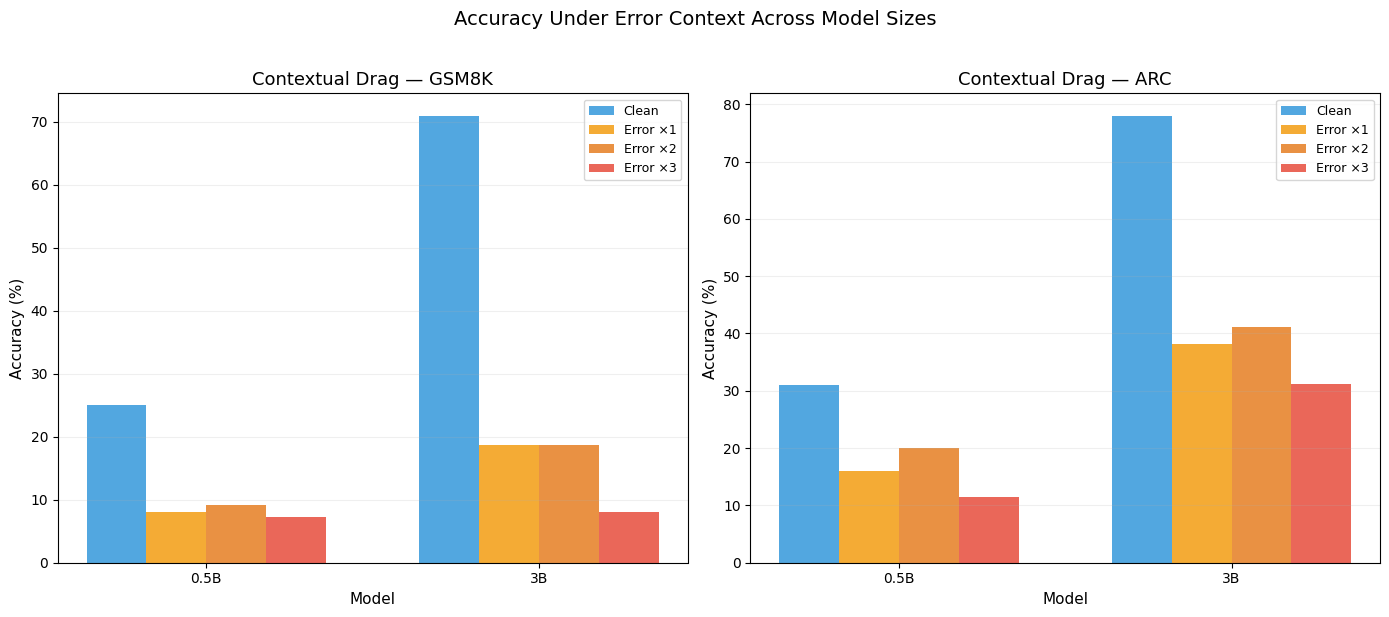

Saved: drag_accuracy_by_model.png


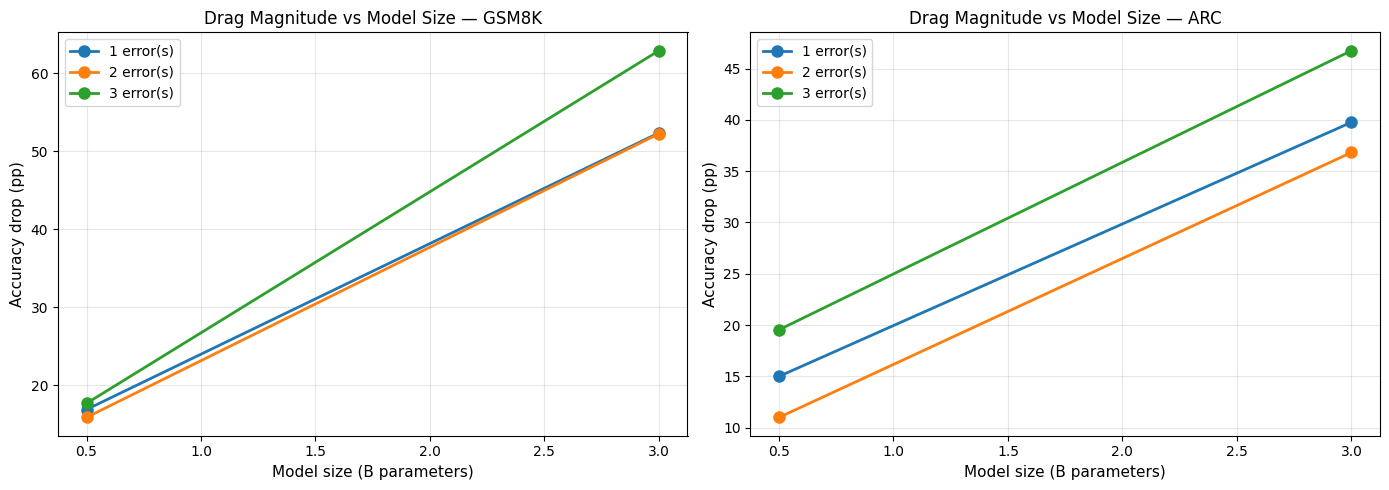

Saved: drag_vs_model_size.png


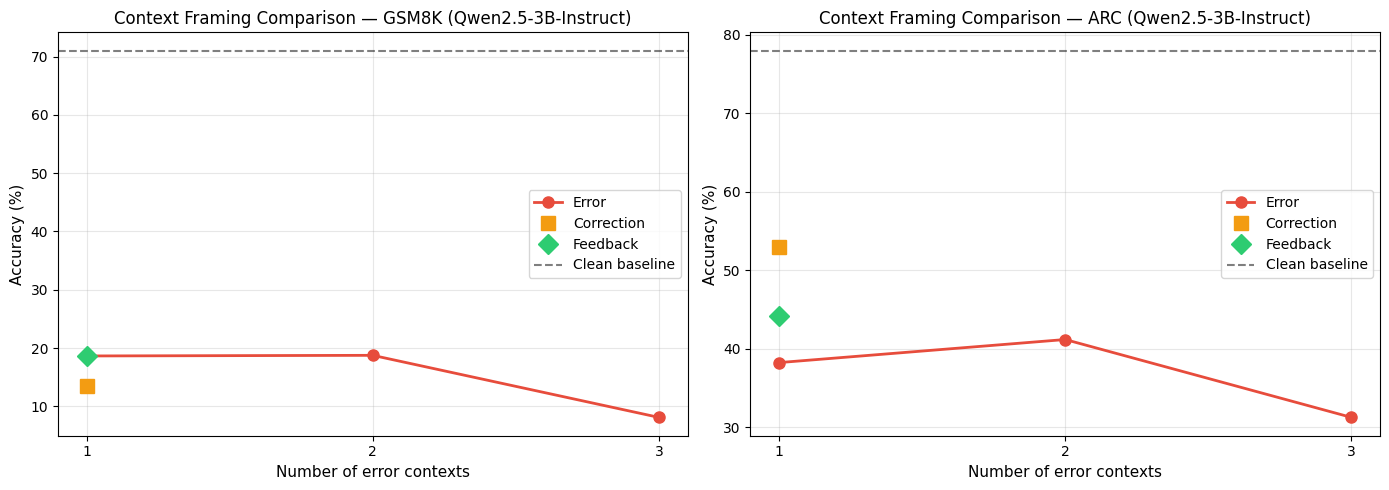

Saved: drag_condition_comparison.png


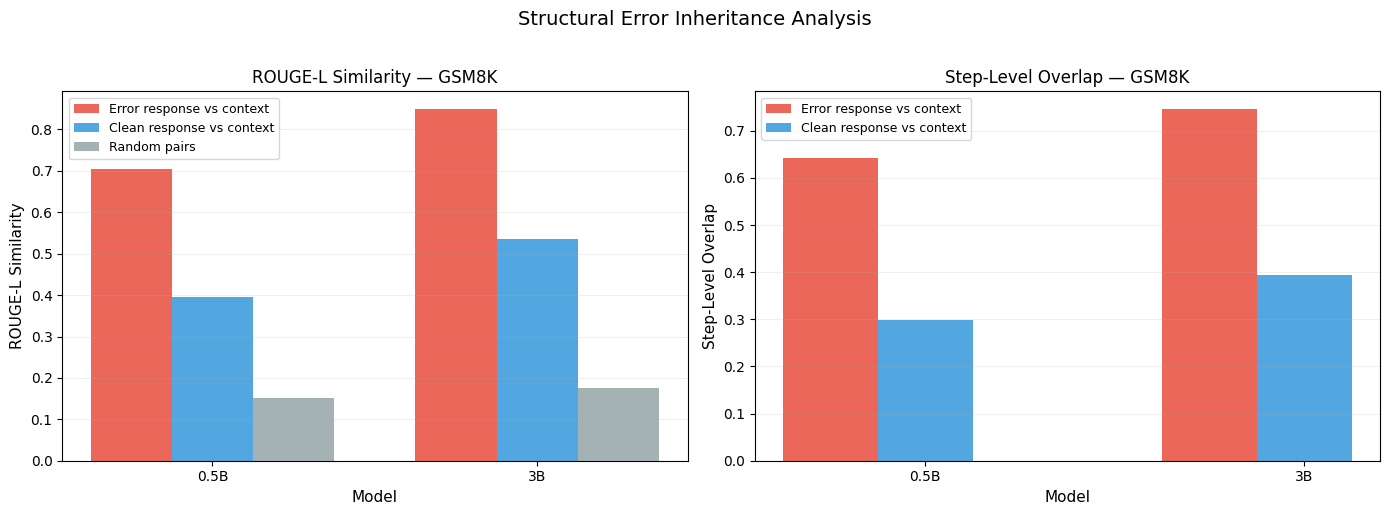

Saved: structural_analysis.png


In [8]:
# =====================================================================
# Plot 1: Accuracy drop by condition and model (core drag result)
# =====================================================================

model_short_names = [
    m.split("/")[-1].replace("Qwen2.5-", "").replace("-Instruct", "") for m in MODEL_IDS
]
model_full_names = [m.split("/")[-1] for m in MODEL_IDS]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, benchmark in zip(axes, ["gsm8k", "arc"]):
    x = np.arange(len(model_short_names))
    width = 0.18

    # Clean baseline
    clean_accs = []
    for mname in model_full_names:
        r = all_experiment_results.get((mname, benchmark, "clean", 0))
        clean_accs.append(r["accuracy"] * 100 if r else 0)

    bars_clean = ax.bar(
        x - 1.5 * width, clean_accs, width, label="Clean", color="#3498db", alpha=0.85
    )

    # Error conditions (1, 2, 3 errors)
    colors_err = ["#f39c12", "#e67e22", "#e74c3c"]
    for i, n_err in enumerate(NUM_ERROR_COUNTS):
        accs = []
        for mname in model_full_names:
            r = all_experiment_results.get((mname, benchmark, "error", n_err))
            accs.append(r["accuracy"] * 100 if r else 0)
        ax.bar(
            x + (i - 0.5) * width,
            accs,
            width,
            label=f"Error ×{n_err}",
            color=colors_err[i],
            alpha=0.85,
        )

    ax.set_xlabel("Model", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_title(f"Contextual Drag — {benchmark.upper()}", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(model_short_names, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis="y")

plt.suptitle("Accuracy Under Error Context Across Model Sizes", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("drag_accuracy_by_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drag_accuracy_by_model.png")


# =====================================================================
# Plot 2: Drag magnitude (accuracy drop) vs model size
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_sizes = [0.5, 3.0]  # billions — matches MODEL_IDS

for ax, benchmark in zip(axes, ["gsm8k", "arc"]):
    for n_err in NUM_ERROR_COUNTS:
        drops = []
        for mname in model_full_names:
            clean = all_experiment_results.get((mname, benchmark, "clean", 0))
            error = all_experiment_results.get((mname, benchmark, "error", n_err))
            if clean and error:
                drops.append((clean["accuracy"] - error["accuracy"]) * 100)
            else:
                drops.append(0)

        ax.plot(
            model_sizes,
            drops,
            "o-",
            label=f"{n_err} error(s)",
            linewidth=2,
            markersize=8,
        )

    ax.set_xlabel("Model size (B parameters)", fontsize=11)
    ax.set_ylabel("Accuracy drop (pp)", fontsize=11)
    ax.set_title(f"Drag Magnitude vs Model Size — {benchmark.upper()}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("drag_vs_model_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drag_vs_model_size.png")


# =====================================================================
# Plot 3: Condition comparison — error vs correction vs feedback
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, benchmark in zip(axes, ["gsm8k", "arc"]):
    # Use 3B model (largest) as the reference
    ref_model = model_full_names[-1]

    clean_acc = (
        all_experiment_results.get((ref_model, benchmark, "clean", 0), {}).get(
            "accuracy", 0
        )
        * 100
    )

    # Error has full sweep (1,2,3); correction and feedback at 1 only
    # Plot error as a line, correction/feedback as single points
    error_accs = []
    for n_err in NUM_ERROR_COUNTS:
        r = all_experiment_results.get((ref_model, benchmark, "error", n_err))
        error_accs.append(r["accuracy"] * 100 if r else 0)
    ax.plot(
        NUM_ERROR_COUNTS,
        error_accs,
        "o-",
        color="#e74c3c",
        label="Error",
        linewidth=2,
        markersize=8,
    )

    # Correction and feedback at n=1 only — plot as single markers
    for cond, color, marker in [
        ("correction", "#f39c12", "s"),
        ("feedback", "#2ecc71", "D"),
    ]:
        r = all_experiment_results.get((ref_model, benchmark, cond, 1))
        if r:
            ax.plot(
                1,
                r["accuracy"] * 100,
                marker,
                color=color,
                label=cond.capitalize(),
                markersize=10,
                zorder=5,
            )

    ax.axhline(
        y=clean_acc, color="black", linestyle="--", alpha=0.5, label="Clean baseline"
    )
    ax.set_xlabel("Number of error contexts", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_title(
        f"Context Framing Comparison — {benchmark.upper()} ({ref_model})", fontsize=12
    )
    ax.legend(fontsize=10)
    ax.set_xticks(NUM_ERROR_COUNTS)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("drag_condition_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drag_condition_comparison.png")


# =====================================================================
# Plot 4: Structural similarity analysis
# =====================================================================

if structural_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, title in [
        (axes[0], "rouge", "ROUGE-L Similarity"),
        (axes[1], "step_overlap", "Step-Level Overlap"),
    ]:
        models_plotted = []
        error_vals = []
        clean_vals = []
        random_vals = []

        for (mname, benchmark), sr in structural_results.items():
            if benchmark == "gsm8k":  # focus on GSM8K for structural analysis
                short = mname.replace("Qwen2.5-", "").replace("-Instruct", "")
                models_plotted.append(short)
                if metric == "rouge":
                    error_vals.append(sr["error_vs_context_rouge"])
                    clean_vals.append(sr["clean_vs_context_rouge"])
                    random_vals.append(sr["random_pair_rouge"])
                else:
                    error_vals.append(sr["error_vs_context_step_overlap"])
                    clean_vals.append(sr["clean_vs_context_step_overlap"])
                    random_vals.append(0)  # no step overlap for random

        if models_plotted:
            x = np.arange(len(models_plotted))
            w = 0.25
            ax.bar(
                x - w,
                error_vals,
                w,
                label="Error response vs context",
                color="#e74c3c",
                alpha=0.85,
            )
            ax.bar(
                x,
                clean_vals,
                w,
                label="Clean response vs context",
                color="#3498db",
                alpha=0.85,
            )
            if metric == "rouge":
                ax.bar(
                    x + w,
                    random_vals,
                    w,
                    label="Random pairs",
                    color="#95a5a6",
                    alpha=0.85,
                )

            ax.set_xlabel("Model", fontsize=11)
            ax.set_ylabel(title, fontsize=11)
            ax.set_title(f"{title} — GSM8K", fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(models_plotted)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.2, axis="y")

    plt.suptitle("Structural Error Inheritance Analysis", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("structural_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: structural_analysis.png")
else:
    print("No structural analysis results to plot.")

## Section 8: Results Summary & Key Takeaways

### Summary Table

The cell below prints a complete results table. After running, update this section based on what you observe.

In [9]:
# =====================================================================
# Summary table: all results at a glance
# =====================================================================

print(f"{'=' * 90}")
print(f"FULL RESULTS SUMMARY")
print(f"{'=' * 90}")

for benchmark in ["gsm8k", "arc"]:
    print(f"\n--- {benchmark.upper()} ---")
    header = f"  {'Model':<25}"
    for cond in [
        "clean",
        "error_1",
        "error_2",
        "error_3",
        "correction_1",
        "feedback_1",
    ]:
        header += f" {cond:>12}"
    print(header)
    print(f"  {'-' * 97}")

    for mname in model_full_names:
        row = f"  {mname:<25}"
        for cond_str in [
            "clean",
            "error_1",
            "error_2",
            "error_3",
            "correction_1",
            "feedback_1",
        ]:
            parts = cond_str.split("_")
            if len(parts) == 1:
                cond, n_err = parts[0], 0
            else:
                cond, n_err = parts[0], int(parts[1])

            r = all_experiment_results.get((mname, benchmark, cond, n_err))
            if r:
                acc = r["accuracy"] * 100
                if cond == "clean":
                    row += f" {acc:>11.1f}%"
                else:
                    clean_r = all_experiment_results.get((mname, benchmark, "clean", 0))
                    clean_acc = clean_r["accuracy"] * 100 if clean_r else 0
                    delta = acc - clean_acc
                    row += f" {acc:>5.1f}({delta:+.1f})"
            else:
                row += f" {'N/A':>12}"
        print(row)

print(f"\n{'=' * 90}")
print("Note: values in parentheses are percentage point change from clean baseline.")

FULL RESULTS SUMMARY

--- GSM8K ---
  Model                            clean      error_1      error_2      error_3 correction_1   feedback_1
  -------------------------------------------------------------------------------------------------
  Qwen2.5-0.5B-Instruct            25.0%   8.1(-16.9)   9.1(-15.9)   7.3(-17.7)  10.1(-14.9)  11.1(-13.9)
  Qwen2.5-3B-Instruct              71.0%  18.6(-52.4)  18.8(-52.2)   8.1(-62.9)  13.6(-57.4)  18.6(-52.4)

--- ARC ---
  Model                            clean      error_1      error_2      error_3 correction_1   feedback_1
  -------------------------------------------------------------------------------------------------
  Qwen2.5-0.5B-Instruct            31.0%  16.0(-15.0)  20.0(-11.0)  11.5(-19.5)  19.0(-12.0)  15.0(-16.0)
  Qwen2.5-3B-Instruct              78.0%  38.2(-39.8)  41.2(-36.8)  31.2(-46.8)  52.9(-25.1)  44.1(-33.9)

Note: values in parentheses are percentage point change from clean baseline.


### Key Takeaways

#### 1. Error context causes massive, consistent performance drops

Both models show large accuracy degradation when wrong solutions appear in context, confirming the paper's core finding:

| Model | Benchmark | Clean | Error ×1 | Drop |
|---|---|---|---|---|
| 0.5B | GSM8K | 25.0% | 8.1% | −16.9 pp |
| 0.5B | ARC | 31.0% | 16.0% | −15.0 pp |
| 3B | GSM8K | 71.0% | 18.6% | −52.4 pp |
| 3B | ARC | 78.0% | 38.2% | −39.8 pp |

The 0.5B drops (−15 to −18 pp) align well with the paper's reported 10–20% range. The 3B drops appear much larger (−40 to −52 pp), but see the caveat on selection bias below.

#### 2. More errors compound the damage — but the first error does most of the work

For the 0.5B model (where skip rates are low enough for reliable comparison), the first error causes the bulk of the drop. Errors 2 and 3 add modest additional degradation on GSM8K (−16.9 → −15.9 → −17.7 pp) and a clearer staircase on ARC (−15.0 → −11.0 → −19.5 pp). The practical implication: even a single failed attempt in context is enough to meaningfully degrade performance.

#### 3. Correction and feedback framing provide limited recovery

Telling the model "the above was wrong" (correction) or providing verifier feedback barely helps on the 0.5B model — correction recovers only ~2 pp on GSM8K (10.1% vs 8.1%) and feedback ~3 pp (11.1% vs 8.1%). The error patterns in context still dominate.

The 3B model on ARC is the one exception: correction recovers 14.7 pp (52.9% vs 38.2%), suggesting that stronger instruction-following capability allows the 3B model to partially override context influence when explicitly told to. This is a notable divergence from the paper, which reports minimal recovery across all models.

#### 4. Structural inheritance is strong and measurable — especially on GSM8K

The ROUGE-L analysis reveals that error-conditioned responses don't just fail more — they fail **in the same way** as the context errors:

| Model | Error vs Context | Clean vs Context | Random Baseline |
|---|---|---|---|
| 0.5B (GSM8K) | **0.705** | 0.395 | 0.152 |
| 3B (GSM8K) | **0.850** | 0.536 | 0.175 |

Error responses are nearly 2× more similar to context errors than clean responses are, far above the random baseline. Step-level overlap tells the same story (0.64 and 0.75 for error-conditioned vs 0.30 and 0.39 for clean). This is the "drag" mechanism — the model copies error *patterns*, not just error *rates*.

The 3B model shows *stronger* structural inheritance than 0.5B (0.85 vs 0.71), suggesting that larger models are more effective pattern copiers — a double-edged sword. ARC shows weaker structural signal, likely because shorter answer traces leave less reasoning surface to analyze.

#### 5. Larger models may suffer more — but selection bias complicates the comparison

The 3B model's drops look dramatically worse than 0.5B's (−52 pp vs −17 pp on GSM8K). However, there is a major confound: **wrong solution generation failed for 63% of 3B GSM8K examples** (the model was too accurate to produce wrong answers at temperature 0.7). This means the error conditions were evaluated only on the ~37–59 hardest examples — precisely the ones where the model is already most vulnerable. The apparent drag is inflated by this selection bias.

The 0.5B results (only 4% skipped) provide the cleaner signal. To fairly compare drag across model sizes, future work should either use a separate weaker model to generate context errors, or increase sampling temperature for stronger models.

### Engineering Callouts

**Silent failure in self-refinement pipelines.** If your pipeline feeds failed attempts back into context (common in "iterative refinement" or "self-correction" systems), you may be actively degrading performance without knowing it. Our results show that even one failed attempt drops accuracy by 15–17 pp on a weak model and by 40+ pp on a stronger one (with caveats). Monitor accuracy per refinement step — if it drops after step 1, you likely have contextual drag.

**The first error is the most dangerous.** Error ×2 and ×3 add marginal damage beyond ×1. If you must include context, limiting to a single retry is far less harmful than an unbounded retry loop.

**Correction framing is not a reliable fix.** Explicitly telling the model "the above was wrong" recovers only 2–3 pp for the 0.5B model. Don't assume instruction-level framing can override the structural influence of error patterns in context.

**Practical mitigation checklist:**

- Always measure refinement step accuracy (not just final accuracy)
- Consider fresh-start strategies after the first failure rather than accumulating retries
- Abstract error feedback rather than showing full failed reasoning traces
- For strong models, correction framing may help on simpler tasks (our 3B ARC result) — but don't rely on it for math/complex reasoning
- The co-evolutionary approach (Agent0, NB 01) sidesteps drag entirely by generating new tasks instead of retrying

### Limitations of This Reproduction

- **Selection bias on 3B.** Wrong solution generation via temperature sampling fails when the model is too accurate (63% failure on 3B GSM8K). This filters evaluations to the hardest examples and inflates reported drag. Future work should use a weaker model or higher temperature for error generation.
- **4-bit quantization** may affect drag severity differently than the paper's full-precision experiments.
- **100-sample subsets** give noisier estimates than the paper's full benchmarks. Confidence intervals are wide, especially for 3B conditions where only 37–59 samples were evaluated.
- **ROUGE-L and Jaccard** are coarser structural metrics than the paper's tree edit distance on parsed reasoning trees. Our structural analysis likely *understates* the true degree of error inheritance.
- **Correction and feedback tested at ×1 only.** We did not test whether framing effects change with more errors in context (the paper suggests they don't, but our 3B ARC divergence makes this worth exploring).

### Connection to Other Notebooks

| Notebook | Relationship |
|---|---|
| **NB 00** | Toy version of this experiment — same drag phenomenon, simulated model, validates the mechanism in a controlled setting |
| **NB 01** | The solution — co-evolutionary self-play (Agent0) sidesteps drag by generating new tasks instead of retrying failed ones |